In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.filterwarnings('ignore')
import os

In [ ]:
training_data_path='/content/drive/MyDrive/Deep_Learning/CNN/training_data'
test_data_path='/content/drive/MyDrive/Deep_Learning/CNN/testing_data'

In [ ]:
os.listdir(training_data_path)

['Night', 'Day', '.ipynb_checkpoints']

In [ ]:
os.listdir(test_data_path)

['Night', 'Day']

In [ ]:
os.listdir(training_data_path+'/Day')

['1.jpg',
 '2.jpg',
 '3.jpg',
 '4.jpg',
 '5.jpg',
 '6.jpg',
 '7.jpg',
 '8.jpg',
 '9.jpg',
 '10.jpg',
 '11.jpg',
 '12.jpg',
 '13.jpg',
 '14.jpg',
 '15.jpg',
 '16.jpg',
 '17.jpg',
 '18.jpg',
 '19.jpg',
 '20.jpg',
 '21.jpg',
 '22.jpg',
 '23.jpg',
 '24.jpg',
 '25.jpg',
 '26.jpg',
 '27.jpg',
 '28.jpg',
 '29.jpg',
 '30.jpg',
 '31.jpg',
 '32.jpg',
 '33.jpg',
 '34.jpg',
 '35.jpg',
 '36.jpg',
 '37.jpg',
 '38.jpg',
 '39.jpg',
 '40.jpg',
 '41.jpg',
 '42.jpg',
 '43.jpg',
 '44.jpg',
 '45.jpg',
 '46.jpg',
 '47.jpg',
 '48.jpg',
 '49.jpg',
 '50.jpg']

In [ ]:
os.listdir(training_data_path+'/Night')

['1.jpg',
 '2.jpg',
 '3.jpg',
 '4.jpg',
 '5.jpg',
 '6.jpg',
 '7.jpg',
 '8.jpg',
 '9.jpg',
 '10.jpg',
 '11.jpg',
 '12.jpg',
 '13.jpg',
 '14.jpg',
 '15.jpg',
 '16.jpg',
 '17.jpg',
 '18.jpg',
 '19.jpg',
 '20.jpg',
 '21.jpg',
 '22.jpg',
 '23.jpg',
 '24.jpg',
 '25.jpg',
 '26.jpg',
 '27.jpg',
 '28.jpg',
 '29.jpg',
 '30.jpg',
 '31.jpg',
 '32.jpg',
 '33.jpg',
 '34.jpg',
 '35.jpg',
 '36.jpg',
 '37.jpg',
 '38.jpg',
 '39.jpg',
 '40.jpg',
 '41.jpg',
 '42.jpg',
 '43.jpg',
 '44.jpg',
 '45.jpg',
 '46.jpg',
 '47.jpg',
 '48.jpg',
 '49.jpg',
 '50.jpg',
 '51.jpg',
 '52.jpg',
 '53.jpg']

In [ ]:
os.listdir(test_data_path+'/Day')

['1.jpg',
 '2.jpg',
 '3.jpg',
 '4.jpg',
 '5.jpg',
 '6.jpg',
 '7.jpg',
 '8.jpg',
 '9.jpg',
 '10.jpg',
 '11.jpg']

In [ ]:
os.listdir(test_data_path+'/Night')

['1.jpg',
 '2.jpg',
 '3.jpg',
 '4.jpg',
 '5.jpg',
 '6.jpg',
 '7.jpg',
 '8.jpg',
 '9.jpg',
 '10.jpg']

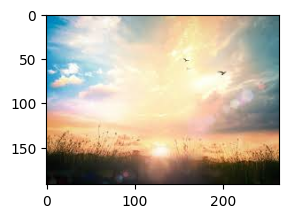

In [ ]:
#showing i [day,night] sample from training data
plt.figure(figsize=(3,3))
day_image = plt.imread(training_data_path+'/Day/10.jpg')
plt.imshow(day_image)

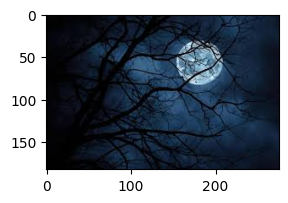

In [ ]:
plt.figure(figsize=(3,3))
night_image=plt.imread(training_data_path+'/Night/10.jpg')
plt.imshow(night_image)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#ImageDataGenerator to add a more formats for image to better understand by the neural networks
train_formats = ImageDataGenerator(rescale=1.0/255,
                                   shear_range=0.2,
                                   horizontal_flip=True,
                                   zoom_range=0.2)

test_format = ImageDataGenerator(rescale=1.0/255)
#only rescale becoz remianing we are giving testing no need of formats

In [ ]:
labels=['Day' , 'Night']

In [ ]:
#applying these formats to training and test data
train_data = train_formats.flow_from_directory(training_data_path,
                                               target_size=(256,256),
                                               classes=labels,
                                               batch_size=10,
                                               class_mode='binary')
train_data

Found 103 images belonging to 2 classes.


In [ ]:
test_data = test_format.flow_from_directory(test_data_path,
                                            target_size=(256,256),
                                            classes=labels,
                                            batch_size=10,
                                            class_mode='binary')

Found 21 images belonging to 2 classes.


***CNN Architecure***(Custom)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D,Flatten
from tensorflow.keras.activations import relu,sigmoid
from sklearn.metrics import accuracy_score , confusion_matrix

In [ ]:
model = Sequential()

#Layer1
model.add(Conv2D(128,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='same',
                 activation='relu',
                 input_shape=(256,256,3)))
model.add(MaxPool2D(pool_size=(2,2)))

#layer2
model.add(Conv2D(64,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2))
)

#layer3
model.add(Conv2D(32,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

#layer4
model.add(Conv2D(16,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

#Flatten layer
model.add(Flatten()) # i dimennsion array

#ANN
model.add(Dense(32, activation='relu'))#HL1
model.add(Dense(16, activation='relu'))#HL2

#output
model.add(Dense(1,activation='sigmoid'))


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,113 (906.69 KB)

 Trainable params: 232,113 (906.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(train_data,
          epochs=5)

Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.4230 - loss: 0.6789
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.7394 - loss: 0.5312
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.7360 - loss: 0.7202
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.9709 - loss: 0.1067
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.8898 - loss: 0.2692


In [ ]:
y_pred=[]
c=  model.predict(test_data)
for i in c:
  if i >0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)

print(y_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]


In [ ]:
y_true = test_data.classes
print(test_data.class_indices)


{'Day': 0, 'Night': 1}


In [ ]:
print(f'Actual:{y_true[:10]}')
print(f'Predicted:{y_pred[:10]}')

Actual:[0 0 0 0 0 0 0 0 0 0]
Predicted:[1, 0, 0, 0, 1, 0, 1, 0, 1, 1]


In [ ]:
#accuracy_score =
accuracy_score(y_true,y_pred)

0.42857142857142855

In [ ]:
confusion_matrix(y_true,y_pred)

array([[6, 5],
       [7, 3]])

In [ ]:
import cv2

In [ ]:
#Testing from google
def testing(path):
  image = cv2.imread(path) #reading the image
  resized_image = cv2.resize(image,(256,256))
  scale_image = resized_image/255.0
  print(scale_image.shape)
  final_image = np.expand_dims(scale_image,axis=0)

  output=model.predict(final_image)
  print(output[0][0])

  plt.imshow(image[:,:,::-1])

  if output[0][0]>0.5:
    print(f'Night')
  else:
    print(f'Day')


(256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
0.11316498
Day


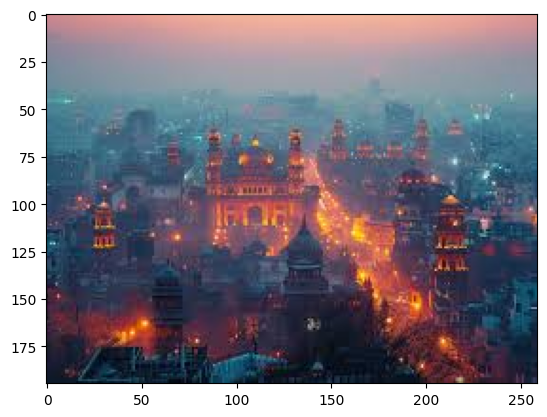

In [ ]:
testing('/content/drive/MyDrive/Deep_Learning/CNN/google_2.jpg')